QUESTION NUMBER 8, PAGE 364, CHAPTER 8 OF THE TEXTBOOK "AN INTRODUCTION TO STATISTICAL LEARNING WITH APPLICATIONS IN PYTHON".

In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will seek to predict Sales using regression trees and related approaches, treating the response as a quantitative variable.

The Carseats dataset in ISLP is a simulated dataset of child car seat sales at 400 stores, with 11 predictors describing store, community, and product characteristics. It’s widely used in decision tree and regression examples because it mixes numeric and categorical predictors.

Predictor	    Type	    Description
CompPrice	    Numeric	    Price charged by competitor at each location
Income	        Numeric	    Community income level (in thousands of dollars)
Advertising	    Numeric	    Local advertising budget (in thousands of dollars)
Population	    Numeric	    Population size in region (in thousands)
Price	        Numeric	    Price company charges for car seats at each site
ShelveLoc	    Categorical	Quality of shelving location (Bad, Medium, Good)
Age	            Numeric	    Average age of local population
Education	    Numeric	    Education level at each location
Urban	        Categorical	Whether store is in an urban location (Yes/No)
US	            Categorical	Whether store is in the US (Yes/No)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ISLP import load_data

QUESTION A

Split the data set into a training set and a test set.

In [2]:
carseats = load_data("Carseats")

# One-hot encode categoricals if present (ShelveLoc, Urban, US in ISLR)
categorical_cols = carseats.select_dtypes(include=['object', 'category']).columns
carseats = pd.get_dummies(carseats, columns=categorical_cols, drop_first=True)

X = carseats.drop(columns=['Sales']).values
y = carseats['Sales'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

QUESTION B

Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

Test MSE (unpruned tree): 4.805344166666667


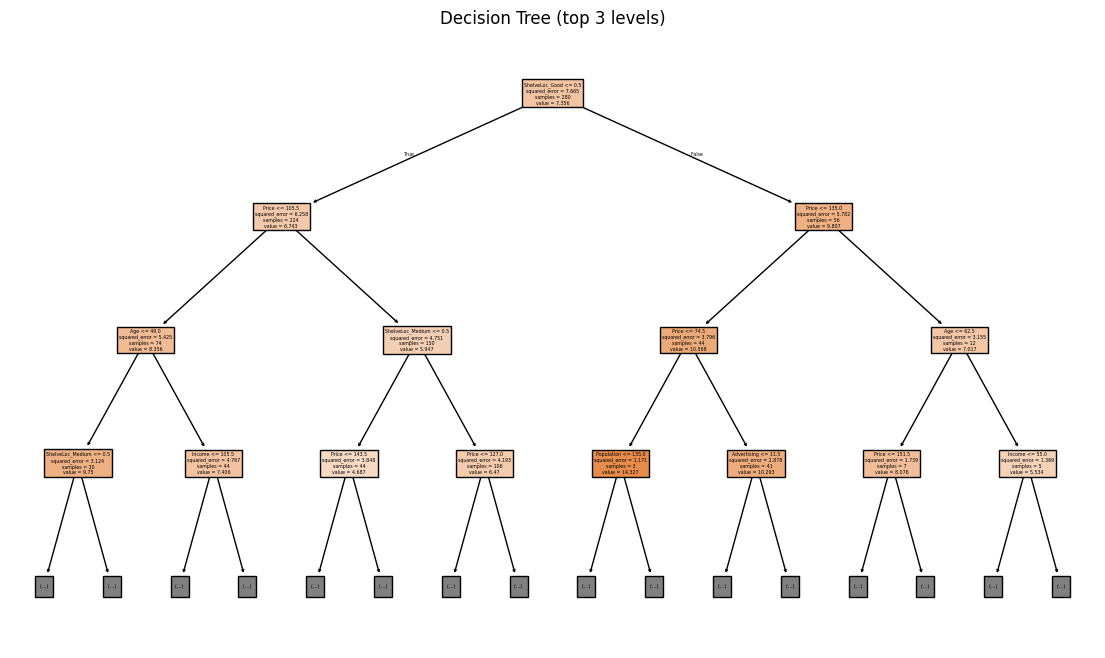

In [3]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
test_mse_tree = mean_squared_error(y_test, y_pred)
print("Test MSE (unpruned tree):", test_mse_tree)

plt.figure(figsize=(14, 8))
plot_tree(tree, feature_names=carseats.drop(columns=['Sales']).columns,
          filled=True, max_depth=3)
plt.title("Decision Tree (top 3 levels)")
plt.show()

QUESTION C

Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [4]:
from sklearn.model_selection import KFold

path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

kf = KFold(n_splits=10, shuffle=True, random_state=42)
alpha_mse = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    fold_mse = []
    for tr_idx, val_idx in kf.split(X_train):
        model.fit(X_train[tr_idx], y_train[tr_idx])
        preds = model.predict(X_train[val_idx])
        fold_mse.append(mean_squared_error(y_train[val_idx], preds))
    alpha_mse.append(np.mean(fold_mse))

best_alpha = ccp_alphas[np.argmin(alpha_mse)]
print("Best ccp_alpha:", best_alpha)

pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)
test_mse_pruned = mean_squared_error(y_test, y_pred_pruned)
print("Test MSE (pruned tree):", test_mse_pruned)


Best ccp_alpha: 0.09824855338477945
Test MSE (pruned tree): 4.962995939319524


QUESTION D

Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

In [5]:
from sklearn.ensemble import BaggingRegressor
from sklearn.inspection import permutation_importance

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=200,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)
test_mse_bag = mean_squared_error(y_test, y_pred_bag)
print("Test MSE (bagging):", test_mse_bag)

perm = permutation_importance(bag, X_test, y_test, n_repeats=10,
                              random_state=42, n_jobs=-1)
importances = pd.Series(perm.importances_mean,
                        index=carseats.drop(columns=['Sales']).columns).sort_values(ascending=False)
print(importances.head(10))


Test MSE (bagging): 2.4880710349374997
ShelveLoc_Good      0.607165
Price               0.507000
CompPrice           0.144134
Age                 0.095041
Advertising         0.077916
ShelveLoc_Medium    0.075075
Income              0.030707
Education           0.002550
Population          0.000260
US_Yes             -0.001658
dtype: float64


QUESTION E

Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

In [6]:
from sklearn.ensemble import RandomForestRegressor

feature_names = carseats.drop(columns=['Sales']).columns
m_values = [int(np.sqrt(X.shape[1])), int(X.shape[1]/3), X.shape[1]]
results = {}

for m in m_values:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    results[m] = mse_rf

    fi = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(f"Random Forest (m={m}) Test MSE:", mse_rf)
    print(fi.head(10))

print("MSE vs m:", results)


Random Forest (m=3) Test MSE: 3.1280586767133434
Price               0.247912
ShelveLoc_Good      0.144835
Age                 0.134183
Advertising         0.098763
CompPrice           0.096908
Population          0.082691
Income              0.077456
Education           0.052375
ShelveLoc_Medium    0.038108
US_Yes              0.014371
dtype: float64
Random Forest (m=3) Test MSE: 3.128058676713344
Price               0.247912
ShelveLoc_Good      0.144835
Age                 0.134183
Advertising         0.098763
CompPrice           0.096908
Population          0.082691
Income              0.077456
Education           0.052375
ShelveLoc_Medium    0.038108
US_Yes              0.014371
dtype: float64
Random Forest (m=11) Test MSE: 2.483043483376675
Price               0.323414
ShelveLoc_Good      0.191970
Age                 0.119546
CompPrice           0.106290
Advertising         0.071229
Income              0.052299
ShelveLoc_Medium    0.050933
Population          0.040482
Education   

QUESTION F

Now analyze the data using BART, and report your results.

In [15]:
from sklearn.metrics import mean_squared_error
from ISLP.bart import BART

# 1. Load Carseats dataset
carseats = pd.read_csv("Carseats.csv")

# 2. Separate predictors and response
X = carseats.drop(columns=['Sales'])
y = carseats['Sales']

# 3. One-hot encode categorical predictors
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Ensure numeric dtype (float64)
X = X.astype(float).values
y = y.astype(float).values

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 6. Fit BART model with explicit hyperparameters
bart = BART(
    num_trees=200,     # number of trees
    burnin=200,        # burn-in iterations
    ndraw=1000,        # posterior samples
    random_state=42,   # reproducibility
    n_jobs=-1          # use all cores
)
bart.fit(X_train, y_train)

# 7. Predict on test set
y_pred_bart = bart.predict(X_test)

# 8. Compute test MSE
test_mse_bart = mean_squared_error(y_test, y_pred_bart)
print("Test MSE (BART):", test_mse_bart)


Test MSE (BART): 1.240523873083126
